# High-z Example 14: HZ9 Outer-Ring Dispersion Anomaly

**EPS Research — High-z Kinematic Corpus Z1**

HZ9 at z=5.5413 has an anomalous outer ring:
sigma(outer) = 4.82 km/s vs sigma(inner) ~ 71-75 km/s.
This produces V/sigma = 36.6 at the outer boundary —
physically implausible and likely a 3DBarolo fit artifact
at the ALMA beam resolution limit.

This is a documented known limitation in the corpus.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20369285  
**arXiv:** 2605.25339  
**Source:** Jones et al. (2021), MNRAS 507, 3540; Le Fevre et al. (2020)  
**Dependencies:** Python 3, numpy, matplotlib

In [ ]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'high_z_kinematic_corpus_Z1.json': 'https://zenodo.org/records/20369285/files/high_z_kinematic_corpus_Z1.json',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {{filename}}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {{filename}}")
        else:
            print(f"  Already present: {{filename}}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('high_z_kinematic_corpus_Z1.json') as f:
    corpus = json.load(f)

galaxies  = corpus['galaxies']
rotators  = [g for g in galaxies if g.get('is_rotator') and g.get('quality_tier')==1]
print(f"Total galaxies: {len(galaxies)}")
print(f"Tier-1 rotators: {len(rotators)}")


Total galaxies: 31
Tier-1 rotators: 8


In [2]:
import numpy as np
# Find HZ9
hz9 = next((g for g in rotators if 'HZ9' in g['galaxy']), None)
if hz9 is None:
    hz9 = next((g for g in galaxies if 'HZ9' in g['galaxy']), None)

if hz9:
    print(f"Galaxy: {hz9['galaxy']}")
    print(f"Redshift: {hz9['redshift']}")
    print(f"\nPer-ring data:")
    print(f"{'Ring':>5} {'R (kpc)':>9} {'Vrot':>8} {'sigma':>8} {'V/sigma':>9}")
    print('-'*45)
    for i, p in enumerate(hz9['data']):
        flag = ' ⚠️ ANOMALY' if p['sigma_kms'] < 10 else ''
        print(f"{i+1:>5} {p['R_kpc']:>9.2f} {p['Vrot_kms']:>8.2f} "
              f"{p['sigma_kms']:>8.2f} {p['v_over_sigma']:>9.2f}{flag}")
    print(f"\nNote: Outer sigma={hz9['data'][-1]['sigma_kms']:.2f} km/s is")
    print(f"      {hz9['data'][0]['sigma_kms']/hz9['data'][-1]['sigma_kms']:.0f}x lower than inner sigma")
    print(f"      This is a known 3DBarolo artifact at beam resolution limit")
else:
    print("HZ9 not found in tier-1 rotators — check corpus")

Galaxy: HZ9
Redshift: 5.5413

Per-ring data:
 Ring   R (kpc)     Vrot    sigma   V/sigma
---------------------------------------------
    1      0.54   155.85    71.10      2.19
    2      1.61   156.77    75.12      2.09
    3      2.68   176.63     4.82     36.65 ⚠️ ANOMALY

Note: Outer sigma=4.82 km/s is
      15x lower than inner sigma
      This is a known 3DBarolo artifact at beam resolution limit


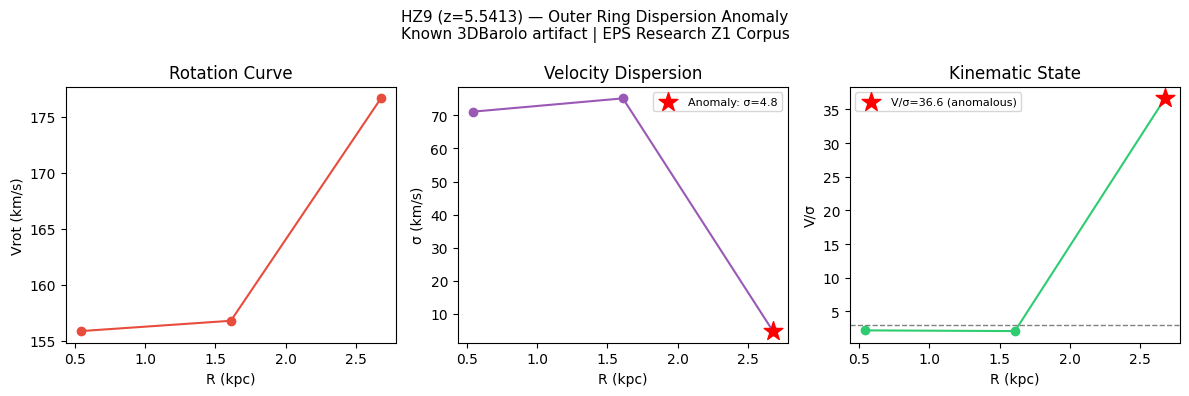

In [3]:
if hz9:
    d = hz9['data']
    R     = [p['R_kpc']      for p in d]
    Vrot  = [p['Vrot_kms']   for p in d]
    sigma = [p['sigma_kms']  for p in d]
    vos   = [p['v_over_sigma'] for p in d]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].plot(R, Vrot, 'o-', color='#e74c3c', lw=1.5, ms=6)
    axes[0].set_xlabel('R (kpc)'); axes[0].set_ylabel('Vrot (km/s)')
    axes[0].set_title('Rotation Curve')

    axes[1].plot(R, sigma, 'o-', color='#9b59b6', lw=1.5, ms=6)
    axes[1].scatter(R[-1], sigma[-1], s=200, color='red', zorder=5,
                    marker='*', label=f'Anomaly: σ={sigma[-1]:.1f}')
    axes[1].set_xlabel('R (kpc)'); axes[1].set_ylabel('σ (km/s)')
    axes[1].set_title('Velocity Dispersion'); axes[1].legend(fontsize=8)

    axes[2].plot(R, vos, 'o-', color='#2ecc71', lw=1.5, ms=6)
    axes[2].scatter(R[-1], vos[-1], s=200, color='red', zorder=5,
                    marker='*', label=f'V/σ={vos[-1]:.1f} (anomalous)')
    axes[2].axhline(3.0, color='gray', ls='--', lw=1)
    axes[2].set_xlabel('R (kpc)'); axes[2].set_ylabel('V/σ')
    axes[2].set_title('Kinematic State'); axes[2].legend(fontsize=8)

    plt.suptitle(f'HZ9 (z={hz9["redshift"]}) — Outer Ring Dispersion Anomaly\n'
                 'Known 3DBarolo artifact | EPS Research Z1 Corpus', fontsize=11)
    plt.tight_layout()
    plt.savefig('hz14_hz9_anomaly.png', dpi=150, bbox_inches='tight')
    plt.show()